In [1]:
from pathlib import Path
import glob
import fitsio
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from acm.estimators.galaxy_clustering.spectrum import PowerSpectrumMultipoles
from acm import setup_logging

def get_hod_fns(cosmo=1, phase=0, redshift=0.5, seed=0):
    """
    Get the list of HOD file names for a given cosmology,
    phase, and redshift.
    """
    base_dir = '/pscratch/sd/n/ntbfin/emulator/hods/z0.5/yuan23_prior/'
    hod_dir = Path(base_dir) / f'c{cosmo:03}_ph{phase:03}/seed{seed}/'
    hod_fns = glob.glob(str(Path(hod_dir) / f'hod*.fits'))
    return sorted(hod_fns)

def get_hod_positions(filename, los='z'):
    """Get redshift-space positions from a HOD file."""
    hod, header = fitsio.read(filename, header=True)
    qpar, qperp = header['Q_PAR'], header['Q_PERP']
    if los == 'x':
        pos = np.c_[hod['X_RSD'], hod['Y_PERP'], hod['Z_PERP']]
        boxsize = np.array([2000/qpar, 2000/qperp, 2000/qperp])
    elif los == 'y':
        pos = np.c_[hod['X_PERP'], hod['Y_RSD'], hod['Z_PERP']]
        boxsize = np.array([2000/qperp, 2000/qpar, 2000/qperp])
    elif los == 'z':
        pos = np.c_[hod['X_PERP'], hod['Y_PERP'], hod['Z_RSD']]
        boxsize = np.array([2000/qperp, 2000/qperp, 2000/qpar])
    return pos, boxsize

def get_box_args(boxsize, cellsize):
    meshsize = (boxsize / cellsize).astype(int)
    return dict(boxsize=boxsize, boxcenter=0.0, meshsize=meshsize)


setup_logging()

# load galaxy catalog for testing
hod_fn = get_hod_fns(cosmo=0, phase=0, redshift=0.5)[54]
positions, boxsize = get_hod_positions(hod_fn, los='z')

box_args = {'boxsize': 2000, 'meshsize': 256, 'boxcenter': 0}

[000029.29]  01-27 15:34  JaxpowerBackend              INFO     Box size: [2000. 2000. 2000.]
[000029.29]  01-27 15:34  JaxpowerBackend              INFO     Box center: [0. 0. 0.]
[000029.29]  01-27 15:34  JaxpowerBackend              INFO     Box meshsize: [256 256 256]
[000029.37]  01-27 15:34  JaxpowerBackend              INFO     Set density contrast in 0.07 s.


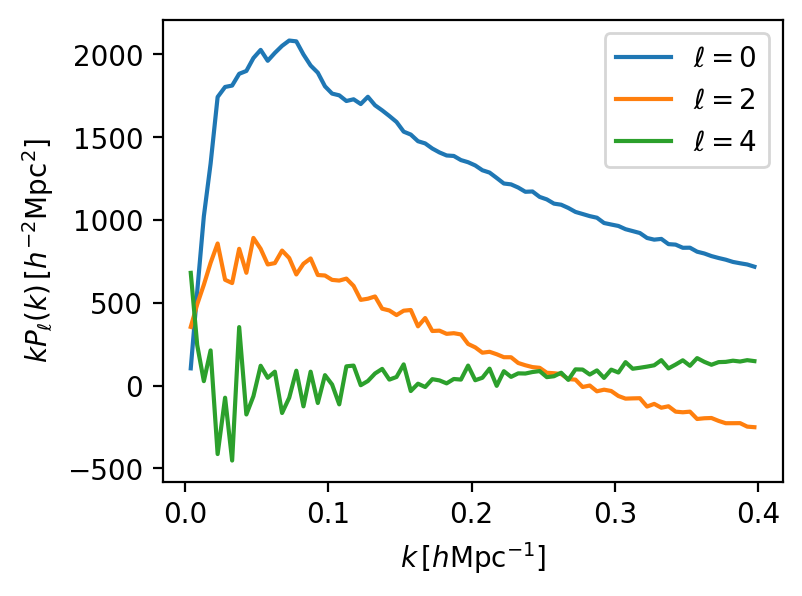

In [4]:
# instantiate class
estimator = PowerSpectrumMultipoles(data_positions=positions, **box_args)

# computation
estimator.set_density_contrast(resampler='tsc', interlacing=3, compensate=True)
spectrum = estimator.compute_spectrum()
k, poles = estimator.get_multipoles(rebin=5)

# plot results
fig, ax = plt.subplots(figsize=(4, 3))
for i, ell in enumerate([0, 2, 4]):
    ax.plot(k, k * poles[i], label=rf'$\ell = {ell}$')
ax.set_xlabel(r'$k\, [h {\rm Mpc}^{-1}$]')
ax.set_ylabel(r'$k P_\ell(k)\, [h^{-2}{\rm Mpc}^2]$')
ax.legend()
plt.show()

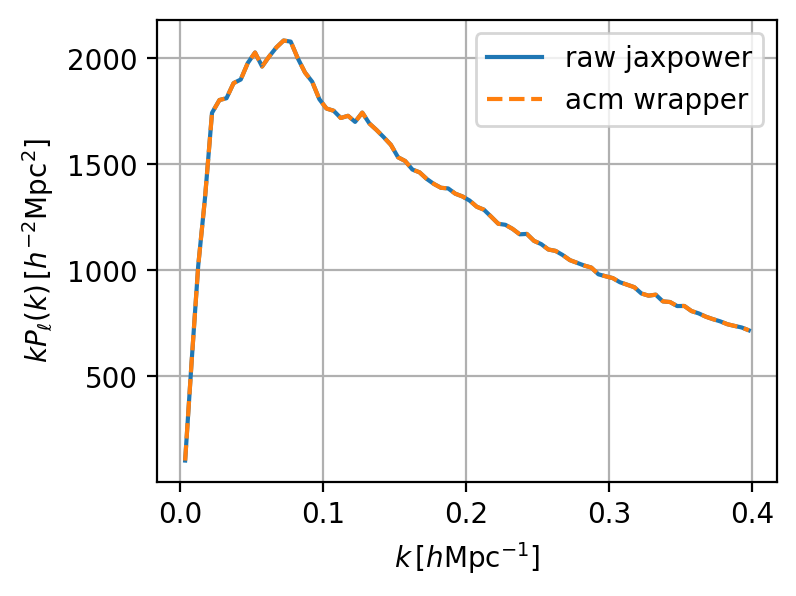

In [5]:
# validate our ACM wrapper against a raw jaxpower computation

def compute_spectrum_jaxpower(positions, ells=(0, 2, 4), los='z', **attrs):
    """Compute the power spectrum of a set of positions using jaxpower."""
    import jax
    from jaxpower import (MeshAttrs, ParticleField, FKPField, BinMesh2SpectrumPoles, get_mesh_attrs, compute_mesh2_spectrum, compute_fkp2_shotnoise)
    mattrs = MeshAttrs(**attrs)
    data = ParticleField(positions, attrs=mattrs, exchange=True, backend='jax')
    mesh = data.paint(resampler='tsc', interlacing=3, compensate=True, out='real')
    mean = mesh.mean()
    mesh = mesh - mean
    bin = BinMesh2SpectrumPoles(mesh.attrs, edges={'step': 0.001}, ells=ells)
    jitted_compute_mesh2_spectrum = jax.jit(compute_mesh2_spectrum, static_argnames=['los'], donate_argnums=[0])
    spectrum = jitted_compute_mesh2_spectrum(mesh, bin=bin, los=los)
    num_shotnoise = compute_fkp2_shotnoise(data, bin=bin)
    spectrum = spectrum.clone(norm=[pole.values('norm') * mean**2 for pole in spectrum], num_shotnoise=num_shotnoise)
    jax.block_until_ready(spectrum)
    return spectrum

spectrum_jaxpower = compute_spectrum_jaxpower(positions=positions, ells=(0, 2, 4), los='z', **box_args)
spectrum_jaxpower = spectrum_jaxpower.select(k=slice(0, None, 5))
poles_jaxpower = [spectrum_jaxpower.get(ell) for ell in (0, 2, 4)]
k = poles_jaxpower[0].coords('k')
poles_jaxpower = [pole.value() for pole in poles_jaxpower]

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(k, k * poles_jaxpower[0], label='raw jaxpower')
ax.plot(k, k * poles[0], label='acm wrapper', ls='--')
ax.legend()
ax.grid()
ax.set_xlabel(r'$k\, [h {\rm Mpc}^{-1}$]')
ax.set_ylabel(r'$k P_\ell(k)\, [h^{-2}{\rm Mpc}^2]$')
plt.show()

[000038.68]  01-27 15:34  CatalogFFTPower              INFO     Painting catalog 1 to mesh CatalogMesh(nmesh=[256 256 256], boxsize=[2000. 2000. 2000.], boxcenter=[0. 0. 0.], dtype=float64).
[000038.83]  01-27 15:34  CatalogMesh                  INFO     Slab 0 ~ 4194304 / 4000000.
[000041.80]  01-27 15:34  CatalogMesh                  INFO     Painted 4000000 out of 4000000 objects to mesh.
[000041.81]  01-27 15:34  CatalogMesh                  INFO     Running interlacing at order 2.
[000042.42]  01-27 15:34  CatalogMesh                  INFO     Slab 0 ~ 4194304 / 4000000.
[000044.96]  01-27 15:34  CatalogMesh                  INFO     Painted 4000000 out of 4000000 objects to mesh.
[000045.91]  01-27 15:34  CatalogFFTPower              INFO     Done painting catalog 1 to mesh.
[000045.92]  01-27 15:34  CatalogFFTPower              INFO     Using 80 k-bins between 0.000 and 0.400.
[000045.92]  01-27 15:34  CatalogFFTPower              INFO     Meshes prepared in elapsed time 7.24 s.

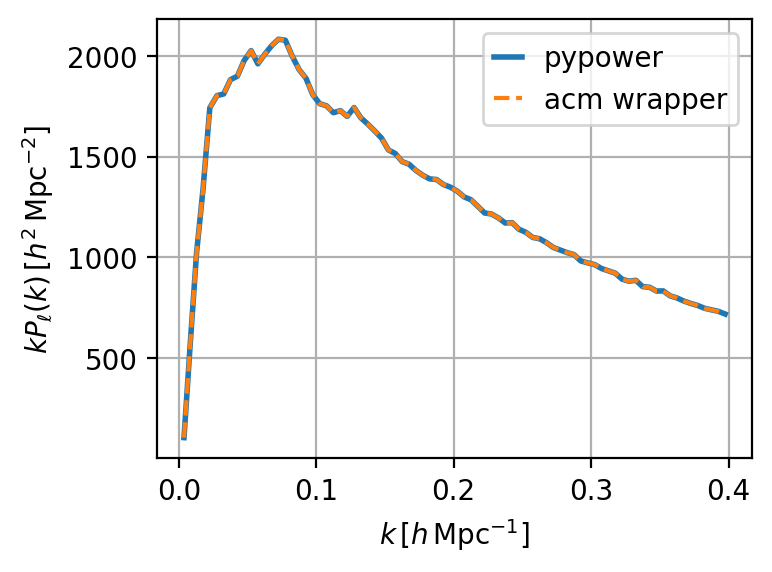

In [6]:
# validate against pypower

def compute_spectrum_pypower(positions, ells=(0, 2, 4)):
    from pypower import CatalogFFTPower
    kwargs = {'boxsize': 2000, 'nmesh': 256, 'boxcenter': 0}
    return CatalogFFTPower(
        data_positions1=positions,
        ells=ells,
        position_type='pos',
        los='z',
        edges={'step': 0.001*5},
        **kwargs,
    ).poles

spectrum_pypower = compute_spectrum_pypower(positions)
k_pypower, poles_pypower = spectrum_pypower(ell=(0, 2, 4), return_k=True, complex=False)

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(k_pypower, k_pypower * poles_pypower[0], lw=2.0, label='pypower')
ax.plot(k, k * poles[0], label='acm wrapper', ls='--')
ax.set_xlabel(r'$k\, [h\,{\rm Mpc}^{-1}]$')
ax.set_ylabel(r'$k P_{\ell}(k)\, [h^{2}\,{\rm Mpc}^{-2}] $')
ax.legend(handlelength=1.0)
ax.grid()
plt.tight_layout()
plt.show()
